# Tutorial 06 - Cross-sectional rotation and portfolio construction

This notebook turns DeTime features into a portfolio ranking language: trend decides direction, cycle adjusts timing, residual controls overextension and volume/reconstruction features control reliability.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from quant_trading.data import load_bundled_real_ohlcv_panel, ohlcv_audit_report
from quant_trading.features import walkforward_decompose_ohlcv
from quant_trading.decomposition_features import feature_coverage_report, build_feature_table
from quant_trading.strategy_baselines import buy_and_hold_weights
from quant_trading.strategy_rotation import (
    classic_momentum_rotation_weights, detime_cross_sectional_score,
    detime_long_short_rotation_weights, detime_rotation_weights,
    rotation_diagnostic_table, volume_availability,
)
from quant_trading.validation import compare_weight_strategies, turnover_report

## 1. Load real offline market data

In [2]:
tickers = ["AUDUSD=X", "NZDUSD=X", "EURUSD=X", "GBPUSD=X"]
ohlcv = load_bundled_real_ohlcv_panel(tickers, min_observations=120)
ohlcv = {field: table.tail(760).copy() for field, table in ohlcv.items()}
prices = ohlcv["Close"]
volumes = ohlcv.get("Volume")
print("volume_available:", volume_availability(volumes))
ohlcv_audit_report(ohlcv)


volume_available: False


,ticker,first_timestamp,last_timestamp,observations,close_missing_ratio,volume_missing_ratio,zero_volume_ratio,min_close,max_close,median_volume
0,AUDUSD=X,2015-02-02,2018-01-02,760,0.0,0.0,1.0,0.686106,0.811293,0.0
1,NZDUSD=X,2015-02-02,2018-01-02,760,0.0,0.0,1.0,0.626684,0.772380,0.0
2,EURUSD=X,2015-02-02,2018-01-02,760,0.0,0.0,1.0,1.039047,1.202906,0.0
3,GBPUSD=X,2015-02-02,2018-01-02,760,0.0,0.0,1.0,1.203935,1.588512,0.0


## 2. Build walk-forward asset features

In [3]:
features = walkforward_decompose_ohlcv(
    ohlcv,
    method="STL",
    period="auto",
    period_candidates=(63, 126, 252),
    train_window=504,
    step=5,
    z_window=63,
)
feature_coverage_report(features).query("feature in ['trend_slope', 'trend_strength', 'cycle_slope', 'residual_z', 'residual_abs_z', 'volume_participation']").head(18)


,feature,asset,observations,non_null,coverage,first_valid,last_valid
12,trend_slope,AUDUSD=X,760,257,0.338158,2017-01-05,2018-01-02
13,trend_slope,NZDUSD=X,760,257,0.338158,2017-01-05,2018-01-02
14,trend_slope,EURUSD=X,760,257,0.338158,2017-01-05,2018-01-02
15,trend_slope,GBPUSD=X,760,257,0.338158,2017-01-05,2018-01-02
20,trend_strength,AUDUSD=X,760,257,0.338158,2017-01-05,2018-01-02
21,trend_strength,NZDUSD=X,760,257,0.338158,2017-01-05,2018-01-02
22,trend_strength,EURUSD=X,760,257,0.338158,2017-01-05,2018-01-02
23,trend_strength,GBPUSD=X,760,257,0.338158,2017-01-05,2018-01-02
32,cycle_slope,AUDUSD=X,760,257,0.338158,2017-01-05,2018-01-02
33,cycle_slope,NZDUSD=X,760,257,0.338158,2017-01-05,2018-01-02


In [4]:
build_feature_table(prices, features).tail(3).iloc[:, :12].round(4)

component_stability                               cycle           \
                      AUDUSD=X EURUSD=X GBPUSD=X NZDUSD=X AUDUSD=X EURUSD=X   
Date                                                                          
2017-12-29              0.9957   0.9939   0.9935   0.9935  -0.0227  -0.0174   
2018-01-01              0.9959   0.9943   0.9932   0.9941  -0.0147  -0.0086   
2018-01-02              0.9959   0.9943   0.9932   0.9941  -0.0147  -0.0086   

                             cycle_amplitude                             
           GBPUSD=X NZDUSD=X        AUDUSD=X EURUSD=X GBPUSD=X NZDUSD=X  
Date                                                                     
2017-12-29   0.0056  -0.0092          0.0306   0.0198   0.0103   0.0311  
2018-01-01   0.0114   0.0075          0.0306   0.0187   0.0100   0.0304  
2018-01-02   0.0114   0.0075          0.0306   0.0187   0.0100   0.0304

## 3. Inspect the DeTime rotation score

In [5]:
score = detime_cross_sectional_score(prices, features)
score.tail(5).round(3)

,AUDUSD=X,NZDUSD=X,EURUSD=X,GBPUSD=X
Date,,,,
2017-12-27,1.894,0.294,2.531,1.656
2017-12-28,1.894,0.294,2.531,1.656
2017-12-29,1.894,0.294,2.531,1.656
2018-01-01,1.656,0.644,2.519,1.556
2018-01-02,1.656,0.644,2.519,1.556


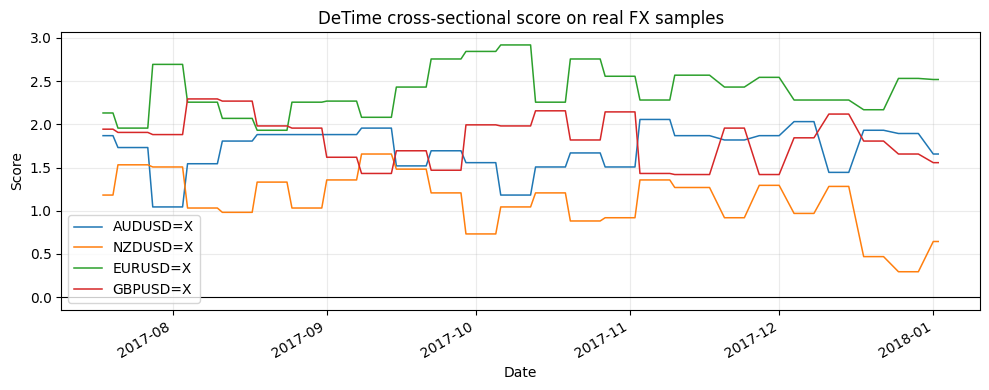

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
score.tail(120).plot(ax=ax, linewidth=1.1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("DeTime cross-sectional score on real FX samples")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [7]:
rotation_diagnostic_table(prices, features, tail=2).round(4)

,date,asset,score,trend_strength,cycle_slope,residual_z,volume_participation
0,2018-01-01,EURUSD=X,2.5188,0.1228,0.0016,-0.4600,1.25
1,2018-01-01,AUDUSD=X,1.6563,0.0496,0.0010,0.2019,1.25
2,2018-01-01,GBPUSD=X,1.5562,0.0393,0.0011,0.1007,1.25
3,2018-01-01,NZDUSD=X,0.6438,-0.0190,0.0036,-0.8123,1.25
4,2018-01-02,EURUSD=X,2.5188,0.1228,0.0016,-0.4600,1.25
5,2018-01-02,AUDUSD=X,1.6563,0.0496,0.0010,0.2019,1.25
6,2018-01-02,GBPUSD=X,1.5562,0.0393,0.0011,0.1007,1.25
7,2018-01-02,NZDUSD=X,0.6438,-0.0190,0.0036,-0.8123,1.25


## 4. Backtest a compact rotation suite

In [8]:
strategies = {
    "buy_hold_equal_weight": buy_and_hold_weights(prices),
    "classic_momentum_63_top": classic_momentum_rotation_weights(prices, lookback=63, top_n=2, rebalance_freq="W-FRI", vol_target=None),
    "detime_rotation_top_trend_cycle_residual_volume": detime_rotation_weights(prices, features, top_n=2, rebalance_freq="W-FRI", vol_target=None),
    "detime_rotation_long_short": detime_long_short_rotation_weights(prices, features, top_n=2, bottom_n=2),
}
comparison, results = compare_weight_strategies(prices, strategies, fee_bps=1.0, slippage_bps=2.0)
comparison[["total_return", "sharpe", "max_drawdown", "average_turnover"]].round(4)

,total_return,sharpe,max_drawdown,average_turnover
strategy,,,,
detime_rotation_long_short,0.0052,0.0686,-0.1563,0.0572
detime_rotation_top_trend_cycle_residual_volume,-0.0112,0.0095,-0.1596,0.0289
buy_hold_equal_weight,-0.0115,-0.0085,-0.1234,0.0000
classic_momentum_63_top,-0.0799,-0.2850,-0.1403,0.0461


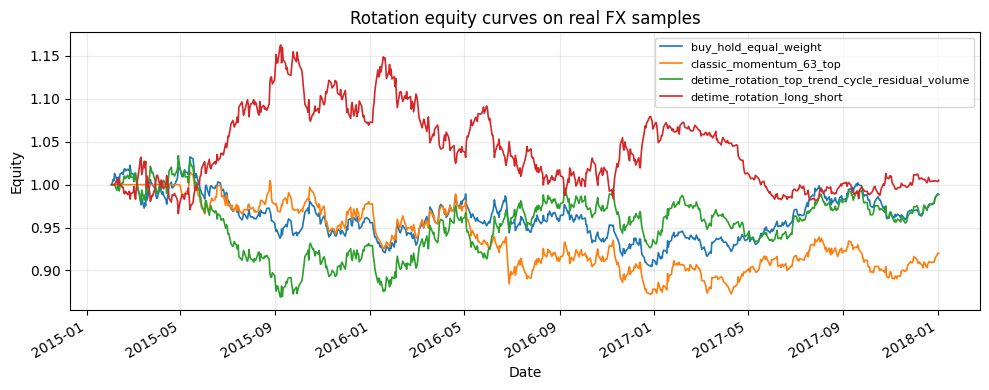

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, result in results.items():
    result.equity.plot(ax=ax, linewidth=1.2, label=name)
ax.set_title("Rotation equity curves on real FX samples")
ax.set_ylabel("Equity")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
turnover_report(strategies).round(4)

,average_turnover,median_turnover,max_turnover,average_gross_exposure
strategy,,,,
buy_hold_equal_weight,0.0000,0.0000,0.0,1.0000
classic_momentum_63_top,0.0461,0.0000,2.0,0.9158
detime_rotation_top_trend_cycle_residual_volume,0.0289,0.0000,2.0,0.9947
detime_rotation_long_short,0.0572,0.0034,3.0,1.2333


## 5. Live-data extension

Run `run_column_06_cross_sectional_rotation.py` without `--use-bundled-sample` to use sector ETFs and real equity/ETF volume. In the bundled FX sample, raw volume is unavailable, so volume is neutral rather than invented.